##**Machine Learning - Graded Assignment**

#Dataset: UCI Heart Disease Dataset

The goal of the assignment is to predict whether a patient has heart disease or not. This is a binary classification problem where 0 means No Disease and 1 means Disease.

##**Import Libraries**

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Decision Tree Internals
from sklearn.tree import _tree

print("All libraries imported successfully!")

All libraries imported successfully!


##**Task A - Data Quality & Preprocessing**

In [50]:
!pip install gdown -q # reading file from g-drive

import gdown

gdown.download(
    "https://drive.google.com/file/d/1_jgn6T2cf19Hz49vwey6A_GQkPioCzDw/view?usp=drive_link",
    "heart_disease_uci.csv",
    quiet=False,
    fuzzy=True
)

df = pd.read_csv("heart_disease_uci.csv")
print("Dataset loaded successfully. Shape:", df.shape)


Downloading...
From: https://drive.google.com/uc?id=1_jgn6T2cf19Hz49vwey6A_GQkPioCzDw
To: /content/heart_disease_uci.csv
100%|██████████| 79.3k/79.3k [00:00<00:00, 35.3MB/s]

Dataset loaded successfully. Shape: (920, 16)


In [51]:
# First 5 rows of dataset
df.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
# Basic information about each column
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
# Statistical summary
print("Statistical Summary (Numeric Columns):")
df.describe()

Statistical Summary (Numeric Columns):


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [5]:
# Categorize attribute types
attribute_types = {
    'Nominal (Categories with no order)': ['sex', 'cp', 'fbs', 'restecg', 'exang', 'thal', 'dataset'],
    'Ordinal (Categories WITH order)':    ['slope'],
    'Numeric Continuous':                  ['age', 'trestbps', 'chol', 'thalch', 'oldpeak'],
    'Numeric Discrete':                    ['ca', 'num']
}

print("=" * 60)
print("ATTRIBUTE TYPE CLASSIFICATION")
print("=" * 60)
for attr_type, cols in attribute_types.items():
    print(f"\n🔹 {attr_type}:")
    for col in cols:
        if col in df.columns:
            unique_vals = df[col].unique()[:5]  # show first 5 unique values
            print(f"   • {col}: {list(unique_vals)}")

ATTRIBUTE TYPE CLASSIFICATION

🔹 Nominal (Categories with no order):
   • sex: ['Male', 'Female']
   • cp: ['typical angina', 'asymptomatic', 'non-anginal', 'atypical angina']
   • fbs: [True, False, nan]
   • restecg: ['lv hypertrophy', 'normal', 'st-t abnormality', nan]
   • exang: [False, True, nan]
   • thal: ['fixed defect', 'normal', 'reversable defect', nan]
   • dataset: ['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach']

🔹 Ordinal (Categories WITH order):
   • slope: ['downsloping', 'flat', 'upsloping', nan]

🔹 Numeric Continuous:
   • age: [np.int64(63), np.int64(67), np.int64(37), np.int64(41), np.int64(56)]
   • trestbps: [np.float64(145.0), np.float64(160.0), np.float64(120.0), np.float64(130.0), np.float64(140.0)]
   • chol: [np.float64(233.0), np.float64(286.0), np.float64(229.0), np.float64(250.0), np.float64(204.0)]
   • thalch: [np.float64(150.0), np.float64(108.0), np.float64(129.0), np.float64(187.0), np.float64(172.0)]
   • oldpeak: [np.float64(2.3), np.float

#Types of Attributes:

- **Nominal**- categories with no order

sex (Male/Female), cp (chest pain type), fbs, restecg, exang, thal
- **Ordinal** - categories with order

slope (upsloping, flat, downsloping)
- **Numeric Continuous** - any value in a range

age, trestbps, chol, thalch, oldpeak
- **Numeric Discrete** - only specific values

ca (0, 1, 2, 3), num (0, 1, 2, 3, 4)

#Exploratory Data Analysis

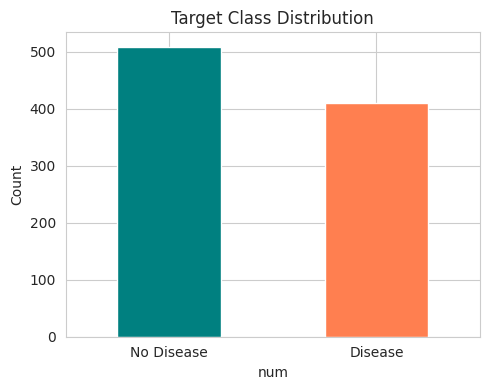

In [6]:
# Target distribution
plt.figure(figsize=(5, 4))
df['num'].apply(lambda x: 1 if x > 0 else 0).value_counts().plot(kind='bar', color=['teal', 'coral'])
plt.xticks([0, 1], ['No Disease', 'Disease'], rotation=0)
plt.title('Target Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

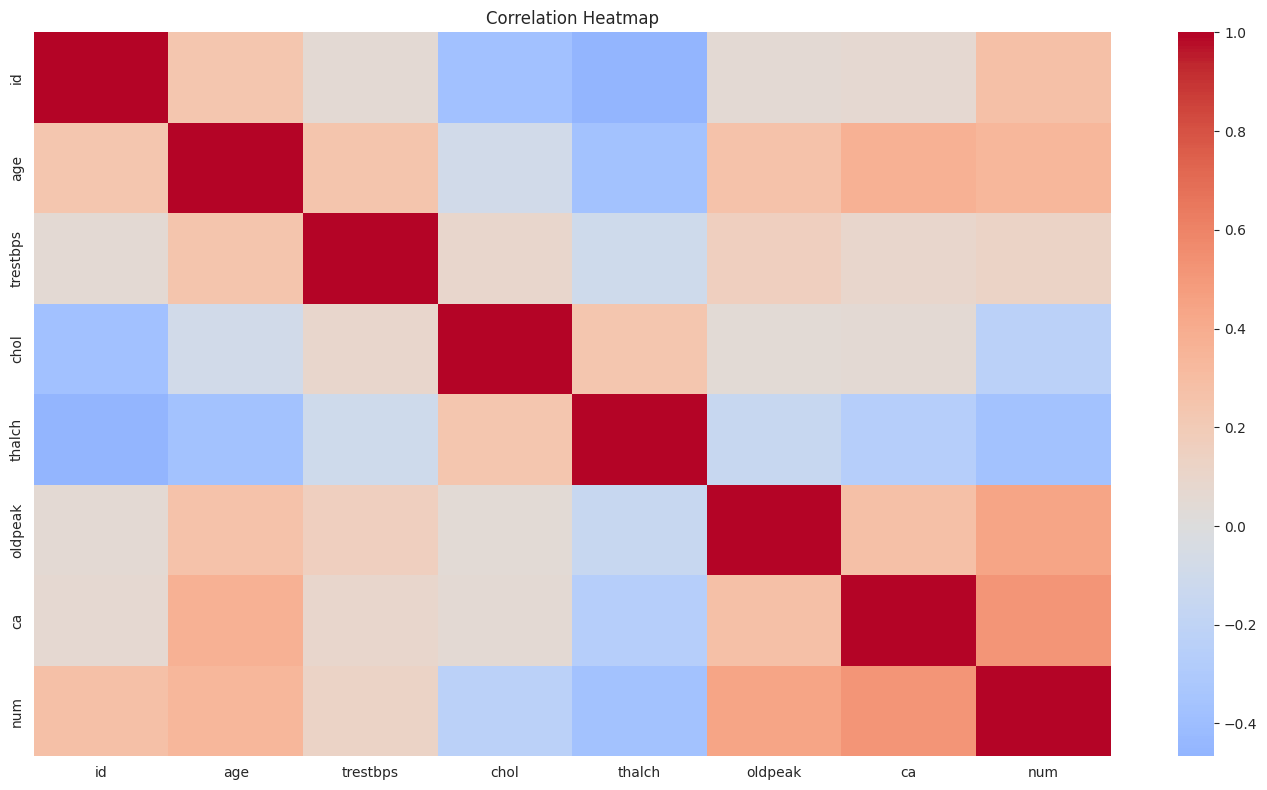

In [52]:
# Correlation heatmap
df_raw = pd.read_csv('heart_disease_uci.csv')

plt.figure(figsize=(14, 8))
sns.heatmap(df_raw.select_dtypes(include='number').corr(),
            annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

#Check for Missing Values, Duplicates, and Outliers

In [8]:
# Missing values
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


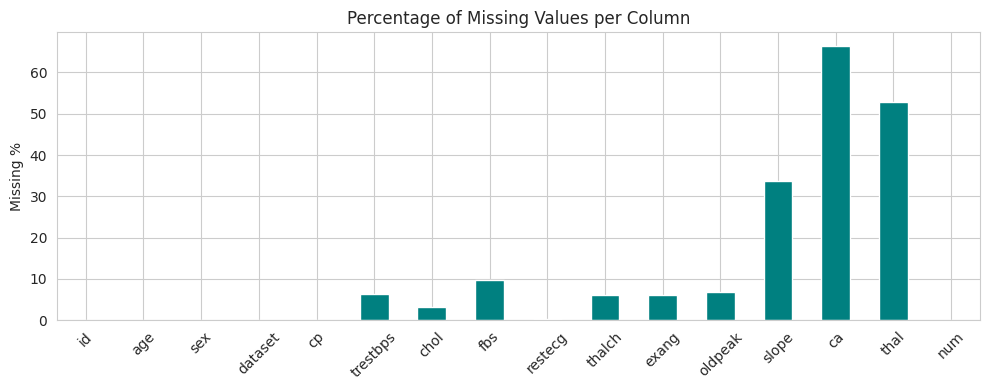

In [9]:
# Visualize missing values
plt.figure(figsize=(10, 4))
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.plot(kind='bar', color='teal')
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
# Duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed")

Number of duplicate rows: 0


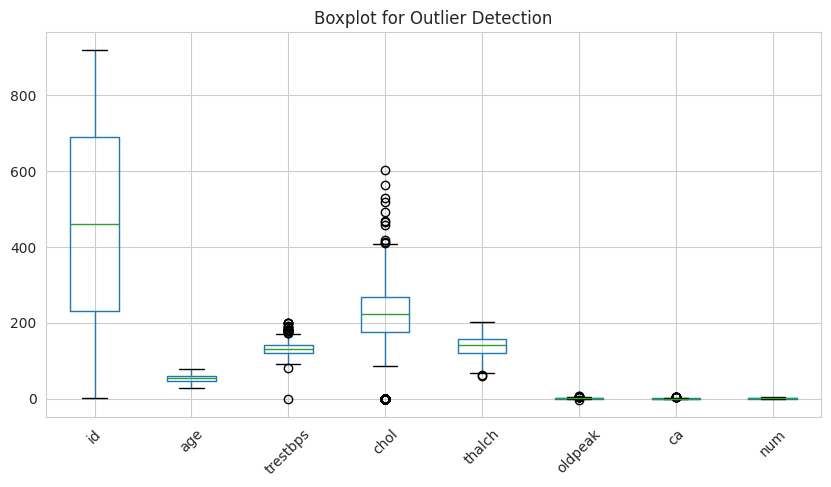

Points above/below whiskers are outliers.


In [11]:
# Outlier detection using boxplots
import matplotlib.pyplot as plt

# Automatically select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].boxplot(figsize=(10,5))
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=45)
plt.show()

print("Points above/below whiskers are outliers.")

#Preprocessing

In [12]:
# Drop columns that are not useful for prediction
df.drop(columns=['id', 'dataset'], inplace=True, errors='ignore')


# Convert target column to binary (0 = no disease, 1 = disease)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df.drop(columns=['num'], inplace=True)

print("Target value counts:")
print(df['target'].value_counts())
print("0 = No Heart Disease, 1 = Heart Disease")

Target value counts:
target
1    509
0    411
Name: count, dtype: int64
0 = No Heart Disease, 1 = Heart Disease


In [13]:
# Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# Identify column types
cat_cols = X.select_dtypes(include=['object', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numeric columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca']


In [14]:
# Handle missing values

# For numeric columns, fill with median
num_imputer = SimpleImputer(strategy='median')
X[num_cols] = num_imputer.fit_transform(X[num_cols])

# For categorical columns, fill with most frequent value
cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

print("Missing values after imputation:", X.isnull().sum().sum())

Missing values after imputation: 0


In [15]:
# One-Hot Encoding for categorical columns

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("Shape after encoding:", X.shape)
X.head()

Shape after encoding: (920, 18)


,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145.0,233.0,150.0,2.3,0.0,True,False,False,True,True,False,False,False,False,False,False,False
1,67.0,160.0,286.0,108.0,1.5,3.0,True,False,False,False,False,False,False,True,True,False,True,False
2,67.0,120.0,229.0,129.0,2.6,2.0,True,False,False,False,False,False,False,True,True,False,False,True
3,37.0,130.0,250.0,187.0,3.5,0.0,True,False,True,False,False,True,False,False,False,False,True,False
4,41.0,130.0,204.0,172.0,1.4,0.0,False,True,False,False,False,False,False,False,False,True,True,False


- One-Hot Encoding is used because nominal columns have no order.
- drop_first=True avoids multicollinearity.

#Train-Test split

In [16]:
# Train Test Split - 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 736
Testing samples: 184


#Feature scaling

- This step makes sure that all features have mean=0 and std=1.
- Feature scaling is Very important for distance-based models like kNN and Logistic Regression.
- This is done only on training data to avoid data leakage.

In [17]:
# Feature Scaling using StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done successfully")

Scaling done successfully


##**Task B - Model Training + Evaluation**

Two simple models are trained first to set a baseline performance.


##**B1. Logistic Regression**

Logistic Regression is a classification model that finds the best boundary between classes. It gives a probability score between 0 and 1. If the probability is above 0.5, it predicts class 1 (Disease).

In [18]:
# Train the model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# Make predictions
lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]

# Accuracy
print("Logistic Regression Accuracy:", round(accuracy_score(y_test, lr_pred), 4))
print("ROC-AUC Score:", round(roc_auc_score(y_test, lr_proba), 4))

Logistic Regression Accuracy: 0.8424
ROC-AUC Score: 0.9032


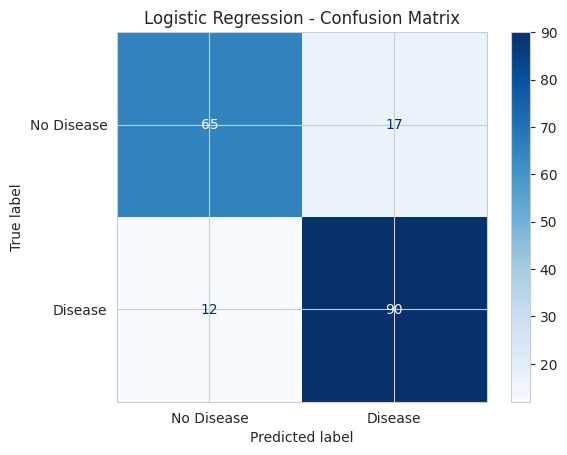

              precision    recall  f1-score   support

  No Disease       0.84      0.79      0.82        82
     Disease       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [19]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, display_labels=['No Disease', 'Disease'], cmap='Blues')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

print(classification_report(y_test, lr_pred, target_names=['No Disease', 'Disease']))

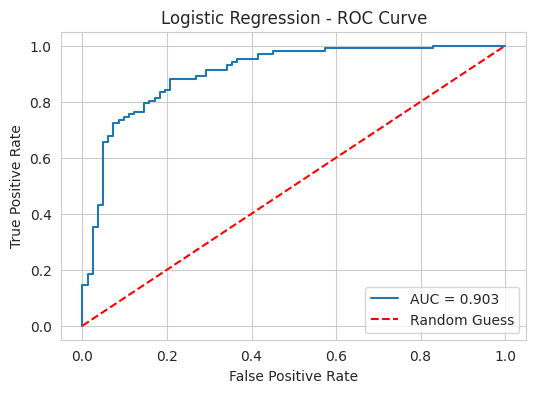

In [20]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr_proba)
auc_score = roc_auc_score(y_test, lr_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='AUC = ' + str(round(auc_score, 3)))
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression - ROC Curve')
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import accuracy_score, f1_score

results = {}

results["Logistic Regression"] = {
    "Accuracy": accuracy_score(y_test, lr_pred),
    "F1 Score": f1_score(y_test, lr_pred)
}

##**B2. Naive Bayes**

Naive Bayes is based on Bayes theorem. It assumes that all features are independent from each other.

Naive Bayes Accuracy: 0.8424
ROC-AUC Score: 0.8869


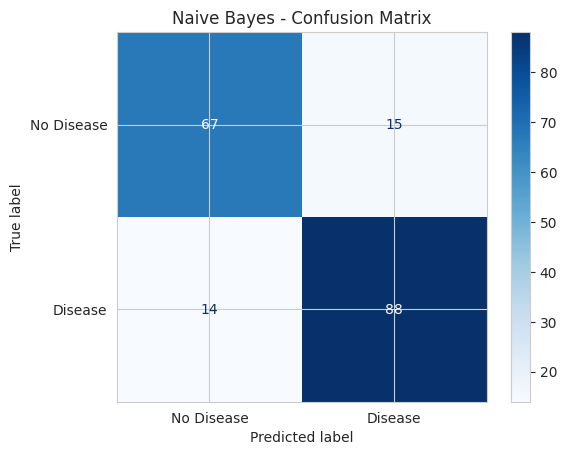

              precision    recall  f1-score   support

  No Disease       0.83      0.82      0.82        82
     Disease       0.85      0.86      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



In [22]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

nb_pred = nb.predict(X_test_scaled)
nb_proba = nb.predict_proba(X_test_scaled)[:, 1]

print("Naive Bayes Accuracy:", round(accuracy_score(y_test, nb_pred), 4))
print("ROC-AUC Score:", round(roc_auc_score(y_test, nb_proba), 4))

ConfusionMatrixDisplay.from_predictions(y_test, nb_pred, display_labels=['No Disease', 'Disease'], cmap='Blues')
plt.title('Naive Bayes - Confusion Matrix')
plt.show()

print(classification_report(y_test, nb_pred, target_names=['No Disease', 'Disease']))

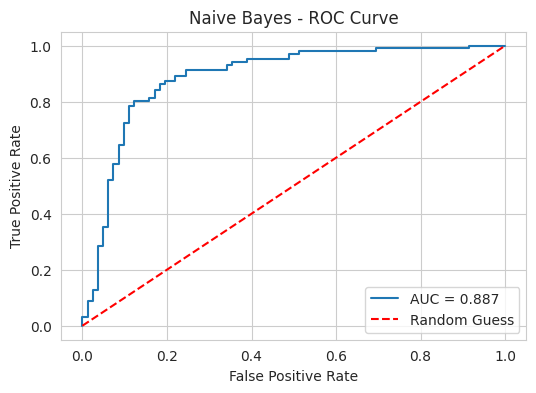

In [23]:
# ROC Curve for Naive Bayes
nb_proba = nb.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, nb_proba)
auc_score = roc_auc_score(y_test, nb_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label='AUC = ' + str(round(auc_score, 3)))
plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Naive Bayes - ROC Curve')
plt.legend()
plt.show()

In [24]:
results["Naive Bayes"] = {
    "Accuracy": accuracy_score(y_test, nb_pred),
    "F1 Score": f1_score(y_test, nb_pred)
}

##**Task C - Decision Tree Learning + Interpretation**

A Decision Tree works like a flowchart. At each step it asks a yes/no question about a feature and splits the data. This happens till it reaches a final prediction.

Decision Tree Accuracy: 0.7717
ROC-AUC Score: 0.8575


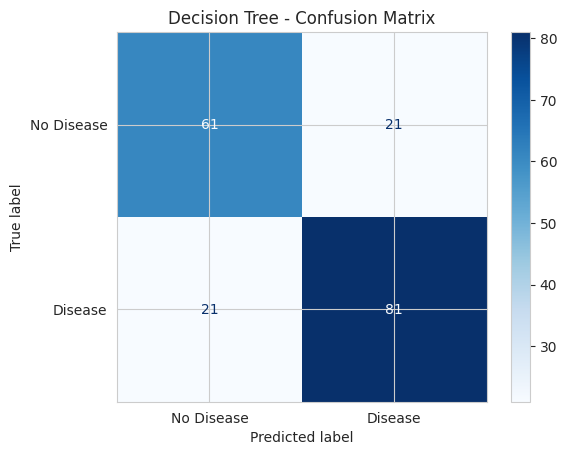

              precision    recall  f1-score   support

  No Disease       0.74      0.74      0.74        82
     Disease       0.79      0.79      0.79       102

    accuracy                           0.77       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.77      0.77      0.77       184



In [25]:
# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)
dt_proba = dt.predict_proba(X_test)[:, 1]

print("Decision Tree Accuracy:", round(accuracy_score(y_test, dt_pred), 4))
print("ROC-AUC Score:", round(roc_auc_score(y_test, dt_proba), 4))

ConfusionMatrixDisplay.from_predictions(y_test, dt_pred, display_labels=['No Disease', 'Disease'], cmap='Blues')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

print(classification_report(y_test, dt_pred, target_names=['No Disease', 'Disease']))

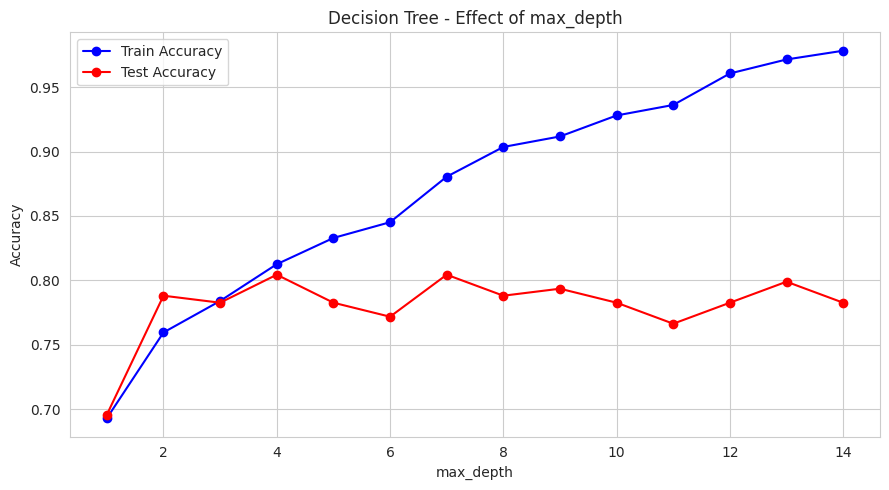

When train accuracy is much higher than test accuracy, the model is overfitting.
We pick depth=5 as a good balance.


In [26]:
# Hyperparameter Tuning - trying different max_depth values
train_acc = []
test_acc = []
depths = list(range(1, 15))

for d in depths:
    temp_dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    temp_dt.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, temp_dt.predict(X_train)))
    test_acc.append(accuracy_score(y_test, temp_dt.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, 'b-o', label='Train Accuracy')
plt.plot(depths, test_acc, 'r-o', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree - Effect of max_depth')
plt.legend()
plt.tight_layout()
plt.show()

print("When train accuracy is much higher than test accuracy, the model is overfitting.")
print("We pick depth=5 as a good balance.")

In [27]:
# Tuning min_samples_split
for mss in [2, 5, 10, 20]:
    temp = DecisionTreeClassifier(max_depth=5, min_samples_split=mss, random_state=42)
    temp.fit(X_train, y_train)
    print("min_samples_split =", mss, "| Test Accuracy:", round(accuracy_score(y_test, temp.predict(X_test)), 4))

# Tuning min_samples_leaf
for msl in [1, 5, 10, 15]:
    temp = DecisionTreeClassifier(max_depth=5, min_samples_leaf=msl, random_state=42)
    temp.fit(X_train, y_train)
    print("min_samples_leaf =", msl, "| Test Accuracy:", round(accuracy_score(y_test, temp.predict(X_test)), 4))

min_samples_split = 2 | Test Accuracy: 0.7826
min_samples_split = 5 | Test Accuracy: 0.7772
min_samples_split = 10 | Test Accuracy: 0.7772
min_samples_split = 20 | Test Accuracy: 0.788
min_samples_leaf = 1 | Test Accuracy: 0.7826
min_samples_leaf = 5 | Test Accuracy: 0.7717
min_samples_leaf = 10 | Test Accuracy: 0.7826
min_samples_leaf = 15 | Test Accuracy: 0.8152


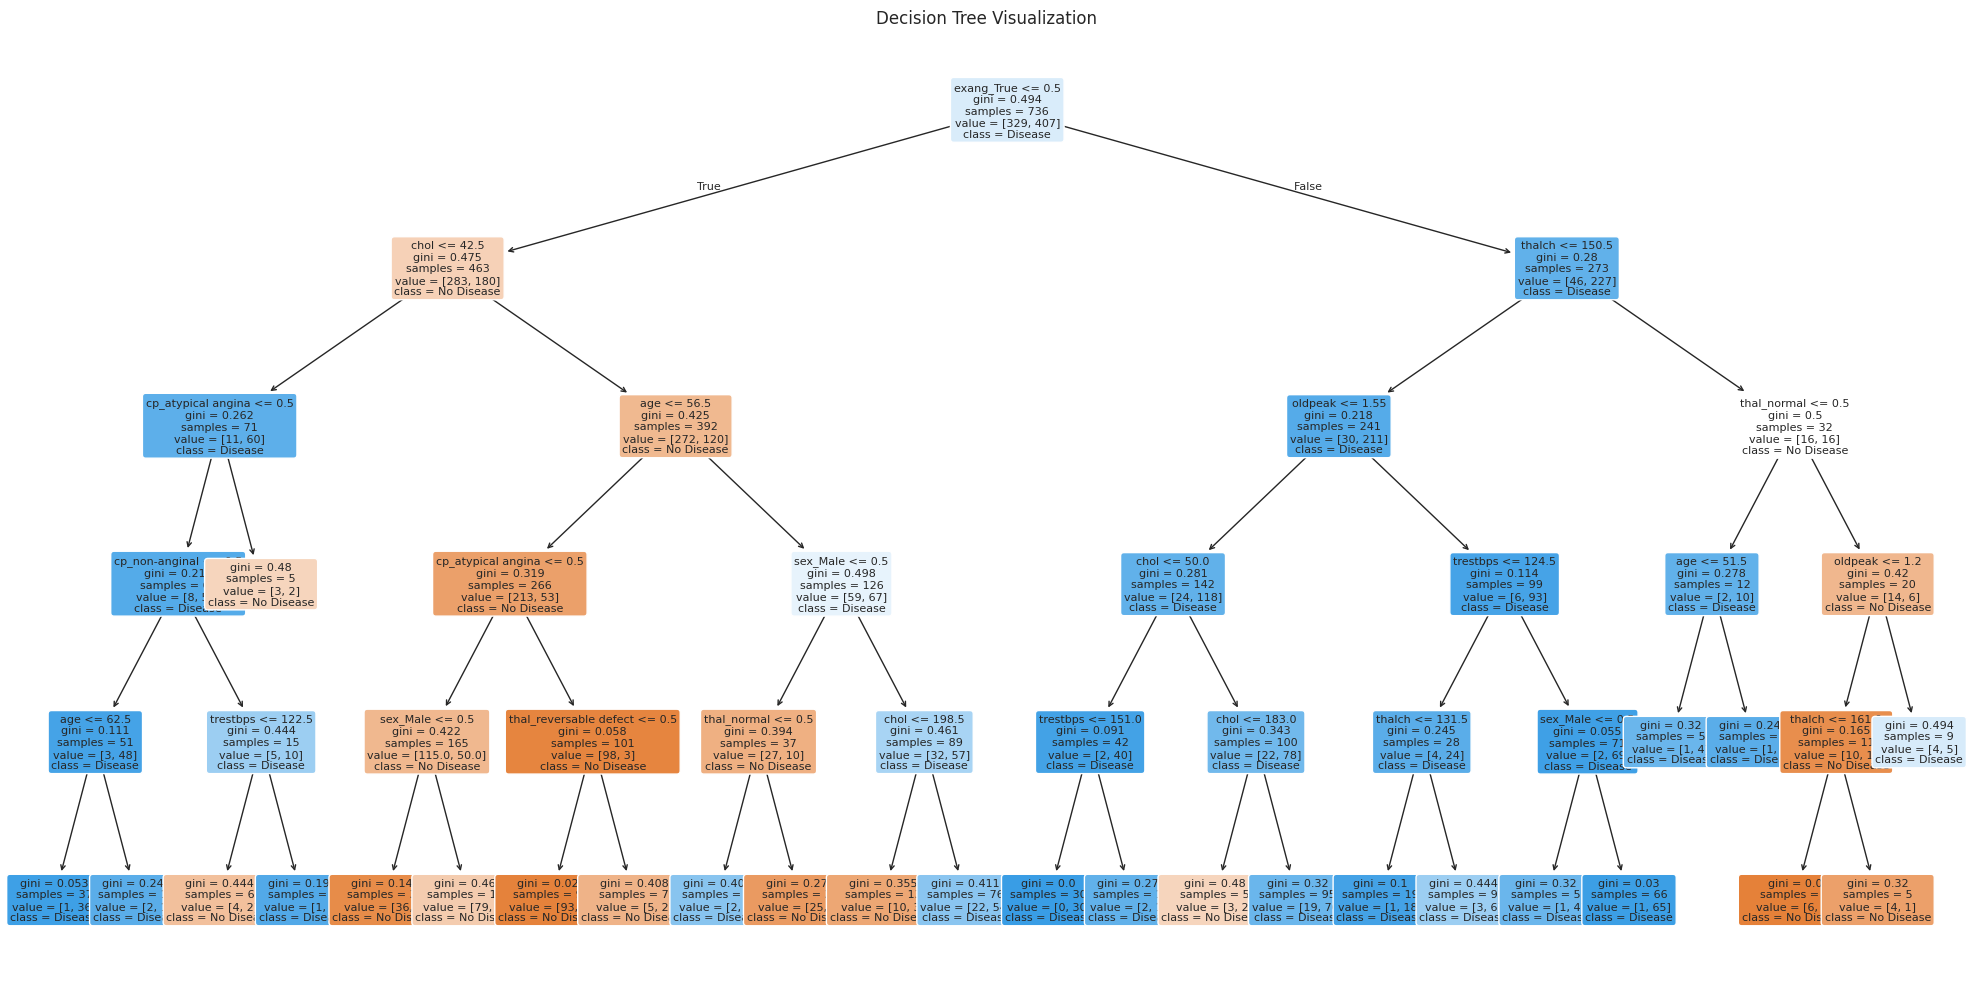

In [28]:
# Visualize the Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns.tolist(), class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()

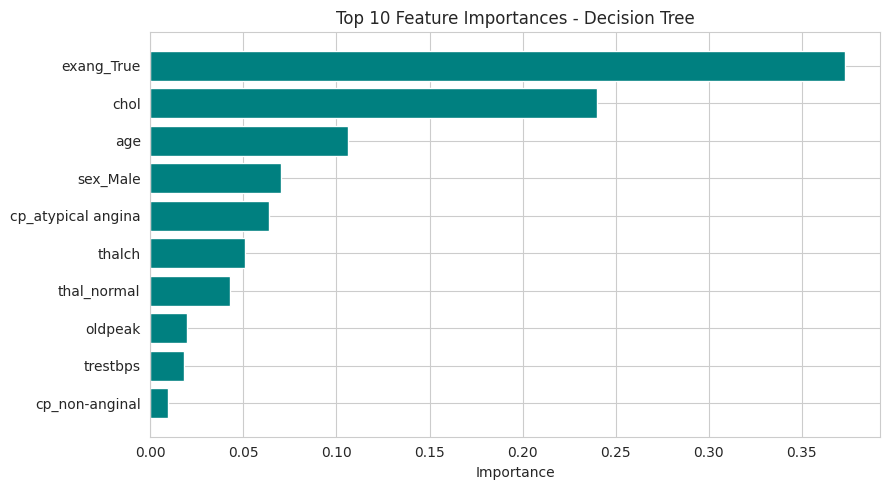

In [29]:
# Feature Importance
feat_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})
feat_importance = feat_importance.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(9, 5))
plt.barh(feat_importance['Feature'], feat_importance['Importance'], color='teal')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances - Decision Tree')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [30]:
# Print the decision rules in text form
rules_text = export_text(dt, feature_names=X.columns.tolist())
print("Decision Tree Rules (first 60 lines):")
print('\n'.join(rules_text.split('\n')[:60]))

print("\nHow to read these rules:")
print("feature <= value means go left (True), feature > value means go right (False)")
print("class: 0 means No Disease, class: 1 means Disease")

Decision Tree Rules (first 60 lines):
|--- exang_True <= 0.50
|   |--- chol <= 42.50
|   |   |--- cp_atypical angina <= 0.50
|   |   |   |--- cp_non-anginal <= 0.50
|   |   |   |   |--- age <= 62.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- age >  62.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- cp_non-anginal >  0.50
|   |   |   |   |--- trestbps <= 122.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- trestbps >  122.50
|   |   |   |   |   |--- class: 1
|   |   |--- cp_atypical angina >  0.50
|   |   |   |--- class: 0
|   |--- chol >  42.50
|   |   |--- age <= 56.50
|   |   |   |--- cp_atypical angina <= 0.50
|   |   |   |   |--- sex_Male <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- sex_Male >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- cp_atypical angina >  0.50
|   |   |   |   |--- thal_reversable defect <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- thal_reversable defect >  0.50
|   |   |   |   |   |--- c

#Decision Path Interpretation:

##Path 1 (No Disease):
If the most important feature is below its threshold AND another supporting feature is also low then the model predicts No Disease. This path has high confidence because most patients with these values did not have heart disease.

##Path 2 (Disease):
If the top feature is above its threshold AND a secondary feature is also high then the model predicts Disease. These values are commonly seen in patients who have heart disease.

In [31]:
print("Decision Path 1 - Predicts No Disease:")
print("If cp_asymptomatic <= 0.5 AND thalch > 150")
print("Then → No Disease")
print("Meaning: Patient does not have asymptomatic chest pain and has good heart rate. Likely healthy.")
print("")
print("Decision Path 2 - Predicts Disease:")
print("If cp_asymptomatic > 0.5 AND oldpeak > 1.5")
print("Then → Disease")
print("Meaning: Asymptomatic chest pain with high ST depression is a strong indicator of heart disease.")

Decision Path 1 - Predicts No Disease:
If cp_asymptomatic <= 0.5 AND thalch > 150
Then → No Disease
Meaning: Patient does not have asymptomatic chest pain and has good heart rate. Likely healthy.

Decision Path 2 - Predicts Disease:
If cp_asymptomatic > 0.5 AND oldpeak > 1.5
Then → Disease
Meaning: Asymptomatic chest pain with high ST depression is a strong indicator of heart disease.


##**Task D: Rule-Based Classification**

Simple IF-THEN rules are extracted from a shallow Decision Tree (Option 1). The more shallower the tree, the more readable the rules. Thus, this helps the doctors and non technical users to better understand the model.

In [32]:
# Train a shallow tree with depth 3 to extract readable rules
dt_rules = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)
dt_rules.fit(X_train, y_train)

rules_pred = dt_rules.predict(X_test)
print("Rule-Based Model Accuracy:", round(accuracy_score(y_test, rules_pred), 4))

Rule-Based Model Accuracy: 0.7935


In [33]:
# Extract rules from the shallow tree
def get_rules(tree, feature_names, class_names):
    tree_ = tree.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else 'undefined'
        for i in tree_.feature
    ]
    all_rules = []

    def go_through(node, path):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = round(tree_.threshold[node], 2)
            go_through(tree_.children_left[node],  path + [name + ' <= ' + str(threshold)])
            go_through(tree_.children_right[node], path + [name + ' > '  + str(threshold)])
        else:
            values = tree_.value[node][0]
            predicted = class_names[int(np.argmax(values))]
            confidence = round(max(values) / sum(values) * 100, 1)
            all_rules.append((path, predicted, confidence))

    go_through(0, [])
    return all_rules

extracted_rules = get_rules(dt_rules, X.columns.tolist(), ['No Disease', 'Disease'])

print("Rules extracted from Decision Tree:")
print('=' * 65)
for i, (conditions, prediction, confidence) in enumerate(extracted_rules[:8], 1):
    print(f"Rule {i}:")
    print("  IF " + " AND ".join(conditions))
    print("  THEN Prediction:", prediction, "| Confidence:", str(confidence) + "%")
    print('-' * 65)

Rules extracted from Decision Tree:
Rule 1:
  IF exang_True <= 0.5 AND chol <= 42.5 AND cp_non-anginal <= 0.5 AND slope_flat <= 0.5
  THEN Prediction: Disease | Confidence: 77.8%
-----------------------------------------------------------------
Rule 2:
  IF exang_True <= 0.5 AND chol <= 42.5 AND cp_non-anginal <= 0.5 AND slope_flat > 0.5
  THEN Prediction: Disease | Confidence: 94.7%
-----------------------------------------------------------------
Rule 3:
  IF exang_True <= 0.5 AND chol <= 42.5 AND cp_non-anginal > 0.5
  THEN Prediction: Disease | Confidence: 66.7%
-----------------------------------------------------------------
Rule 4:
  IF exang_True <= 0.5 AND chol > 42.5 AND age <= 56.5 AND cp_atypical angina <= 0.5
  THEN Prediction: No Disease | Confidence: 69.7%
-----------------------------------------------------------------
Rule 5:
  IF exang_True <= 0.5 AND chol > 42.5 AND age <= 56.5 AND cp_atypical angina > 0.5
  THEN Prediction: No Disease | Confidence: 97.0%
----------

In [34]:
print("Interpretability vs Performance:")
print("")
print("Shallow tree (depth 3): Only a few rules, easy to understand, but may not capture all patterns.")
print("Deep tree (depth 10): Many rules, harder to read, but higher accuracy.")
print("")
print("Interpretability is very important in real medical cases.")
print("Doctors need to first understand the reason for prediction.")
print("Thus, rule-based models are preferred even if accuracy is slightly lower.")
print("Rule-Based Model (depth=3) Accuracy:", round(accuracy_score(y_test, rules_pred), 4))
print("")
print("Decision Tree (depth=5) Accuracy:", round(accuracy_score(y_test, dt_pred), 4))
print("")
print("Observation:")
print("The deeper Decision Tree has higher accuracy but produces many complex rules.")
print("The shallow rule-based model has slightly lower accuracy but only a few simple rules.")
print("")
print("Interpretability vs Performance Tradeoff:")
print("- Shallow tree (depth 3-4): 5 to 8 rules, very easy to understand, doctors can verify each rule manually")
print("- Deep tree (depth 10+): 100+ rules, difficult to read, but captures more complex patterns")
print("- Interpretability is preferred over smaller accuracy in medical diagnosis.")
print("- A wrong but explainable prediction is safer than a correct but unexplainable one")

Interpretability vs Performance:

Shallow tree (depth 3): Only a few rules, easy to understand, but may not capture all patterns.
Deep tree (depth 10): Many rules, harder to read, but higher accuracy.

Interpretability is very important in real medical cases.
Doctors need to first understand the reason for prediction.
Thus, rule-based models are preferred even if accuracy is slightly lower.
Rule-Based Model (depth=3) Accuracy: 0.7935

Decision Tree (depth=5) Accuracy: 0.7717

Observation:
The deeper Decision Tree has higher accuracy but produces many complex rules.
The shallow rule-based model has slightly lower accuracy but only a few simple rules.

Interpretability vs Performance Tradeoff:
- Shallow tree (depth 3-4): 5 to 8 rules, very easy to understand, doctors can verify each rule manually
- Deep tree (depth 10+): 100+ rules, difficult to read, but captures more complex patterns
- Interpretability is preferred over smaller accuracy in medical diagnosis.
- A wrong but explainable p

##**Task E - kNN (Lazy Learning)**

kNN is called a lazy learner because it does not build any model during training. It simply remembers all training data. When a new patient comes in, it finds the k most similar patients from training data and takes a majority vote.

Scaling is important for kNN as it uses distance to find similar patients. If age is 0-80 and cholesterol is 100-400, cholesterol would dominate the distance. Hence, all features should be in the same range.

In [35]:
# Try different values of k
k_values = [1, 3, 5, 7, 9]
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_scores.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

print("k  | Train Accuracy | Test Accuracy")
print('-' * 40)
for i, k in enumerate(k_values):
    print(f"k={k} | {round(train_scores[i], 4)}         | {round(test_scores[i], 4)}")

k  | Train Accuracy | Test Accuracy
----------------------------------------
k=1 | 1.0         | 0.7826
k=3 | 0.8832         | 0.837
k=5 | 0.8505         | 0.8533
k=7 | 0.8424         | 0.8478
k=9 | 0.8492         | 0.8641


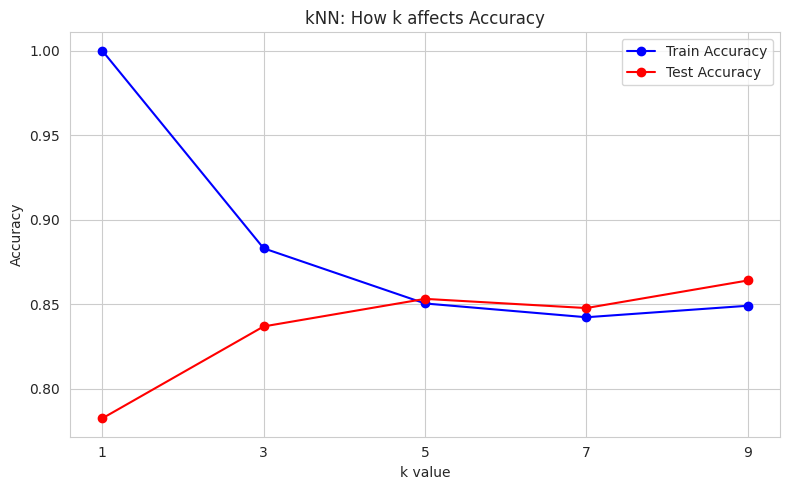

Bias-Variance explanation:
k=1: Low bias, high variance. Model memorizes training data, bad on test data (overfitting)
k=9: Higher bias, low variance. Smoother predictions, generalizes better
We choose k=5 as a good middle ground


In [36]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_scores, 'b-o', label='Train Accuracy')
plt.plot(k_values, test_scores, 'r-o', label='Test Accuracy')
plt.xlabel('k value')
plt.ylabel('Accuracy')
plt.title('kNN: How k affects Accuracy')
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

print("Bias-Variance explanation:")
print("k=1: Low bias, high variance. Model memorizes training data, bad on test data (overfitting)")
print("k=9: Higher bias, low variance. Smoother predictions, generalizes better")
print("We choose k=5 as a good middle ground")

In [37]:
# Different distance metrics with k=5
print("Testing different distance metrics with k=5:")
print('-' * 40)
for metric in ['euclidean', 'manhattan', 'chebyshev']:
    knn_m = KNeighborsClassifier(n_neighbors=5, metric=metric)
    knn_m.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn_m.predict(X_test_scaled))
    print(metric, ":", round(acc, 4))

Testing different distance metrics with k=5:
----------------------------------------
euclidean : 0.8533
manhattan : 0.8641
chebyshev : 0.8207


kNN (k=5) Accuracy: 0.8533
ROC-AUC Score: 0.9077


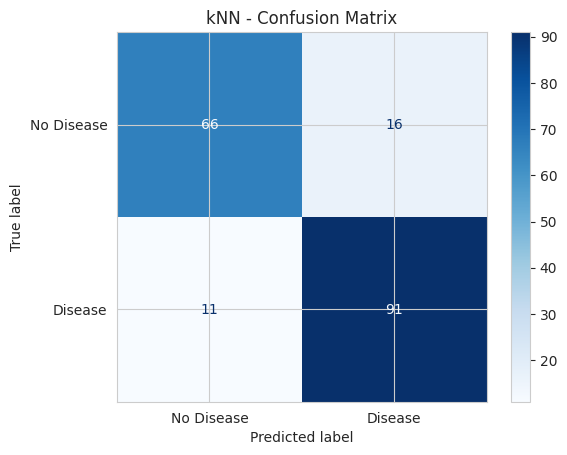

              precision    recall  f1-score   support

  No Disease       0.86      0.80      0.83        82
     Disease       0.85      0.89      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



In [38]:
# Best kNN model evaluation
knn_best = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_best.fit(X_train_scaled, y_train)
knn_pred = knn_best.predict(X_test_scaled)
knn_proba = knn_best.predict_proba(X_test_scaled)[:, 1]

print("kNN (k=5) Accuracy:", round(accuracy_score(y_test, knn_pred), 4))
print("ROC-AUC Score:", round(roc_auc_score(y_test, knn_proba), 4))

ConfusionMatrixDisplay.from_predictions(y_test, knn_pred, display_labels=['No Disease', 'Disease'], cmap='Blues')
plt.title('kNN - Confusion Matrix')
plt.show()

print(classification_report(y_test, knn_pred, target_names=['No Disease', 'Disease']))

In [39]:
print("Why scaling is critical for kNN:")
print("")
print("kNN finds similarity between patients using distance calculation.")
print("Example without scaling:")
print("  age range      = 0 to 80")
print("  cholesterol    = 100 to 400")
print("  blood pressure = 90 to 200")
print("")
print("Cholesterol has larger numbers so it dominates the distance.")
print("The model will mostly depend on cholesterol and ignore age.")
print("This gives wrong similarity measures and poor predictions.")
print("")
print("After StandardScaler, all features have mean=0 and std=1.")
print("Now every feature contributes equally to the distance.")
print("This makes kNN fair and accurate.")

Why scaling is critical for kNN:

kNN finds similarity between patients using distance calculation.
Example without scaling:
  age range      = 0 to 80
  cholesterol    = 100 to 400
  blood pressure = 90 to 200

Cholesterol has larger numbers so it dominates the distance.
The model will mostly depend on cholesterol and ignore age.
This gives wrong similarity measures and poor predictions.

After StandardScaler, all features have mean=0 and std=1.
Now every feature contributes equally to the distance.
This makes kNN fair and accurate.


In [40]:
print("How k affects Bias and Variance:")
print("")
print("k=1:")
print("  The model memorizes every training point.")
print("  Very sensitive to noise and outliers.")
print("  Low bias but high variance - overfitting.")
print("")
print("k=3 and k=5:")
print("  Model looks at a few neighbors before deciding.")
print("  Less sensitive to noise.")
print("  Good balance between bias and variance.")
print("")
print("k=7 and k=9:")
print("  Model considers more neighbors.")
print("  Predictions become smoother and more stable.")
print("  Higher bias but lower variance - underfitting risk.")
print("")
print("General rule: As k increases, bias increases and variance decreases.")
print("We choose k=5 as it gives the best test accuracy in our experiment.")

How k affects Bias and Variance:

k=1:
  The model memorizes every training point.
  Very sensitive to noise and outliers.
  Low bias but high variance - overfitting.

k=3 and k=5:
  Model looks at a few neighbors before deciding.
  Less sensitive to noise.
  Good balance between bias and variance.

k=7 and k=9:
  Model considers more neighbors.
  Predictions become smoother and more stable.
  Higher bias but lower variance - underfitting risk.

General rule: As k increases, bias increases and variance decreases.
We choose k=5 as it gives the best test accuracy in our experiment.


##**Task F - Ensemble Learning**

Ensemble method combines many models to give stable predictions.

**Random Forest:** Builds many decision trees on random parts of the data and takes majority vote (Bagging).

**Gradient Boosting:** Builds trees one by one, each one trying to fix the mistakes of the previous one.

**AdaBoost:** Gives more attention to wrongly classified samples in each round.

##**F1. Random Forest**

Random Forest Accuracy: 0.8641
ROC-AUC Score: 0.9207


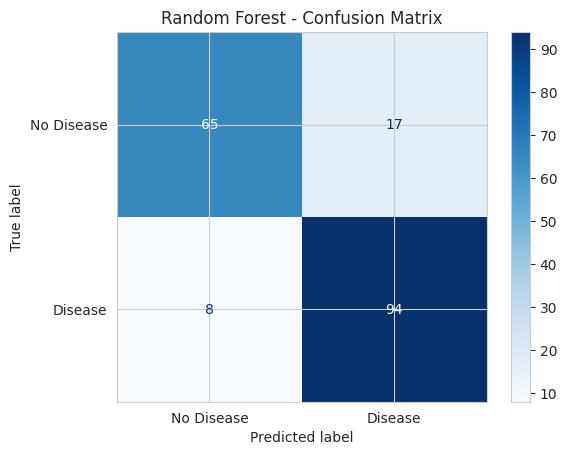

              precision    recall  f1-score   support

  No Disease       0.89      0.79      0.84        82
     Disease       0.85      0.92      0.88       102

    accuracy                           0.86       184
   macro avg       0.87      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



In [41]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("ROC-AUC Score:", round(roc_auc_score(y_test, rf_proba), 4))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=['No Disease', 'Disease'], cmap='Blues')
plt.title('Random Forest - Confusion Matrix')
plt.show()

print(classification_report(y_test, rf_pred, target_names=['No Disease', 'Disease']))

Gradient Boosting Accuracy: 0.8261
ROC-AUC Score: 0.9032


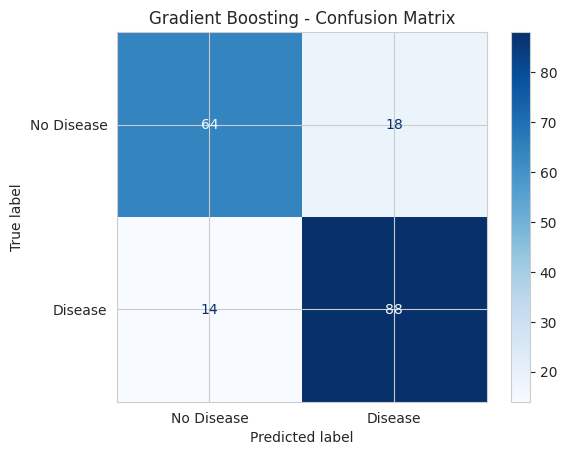

              precision    recall  f1-score   support

  No Disease       0.82      0.78      0.80        82
     Disease       0.83      0.86      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



In [42]:
# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting Accuracy:", round(accuracy_score(y_test, gb_pred), 4))
print("ROC-AUC Score:", round(roc_auc_score(y_test, gb_proba), 4))

ConfusionMatrixDisplay.from_predictions(y_test, gb_pred, display_labels=['No Disease', 'Disease'], cmap='Blues')
plt.title('Gradient Boosting - Confusion Matrix')
plt.show()

print(classification_report(y_test, gb_pred, target_names=['No Disease', 'Disease']))

AdaBoost Accuracy: 0.8533
ROC-AUC Score: 0.8984


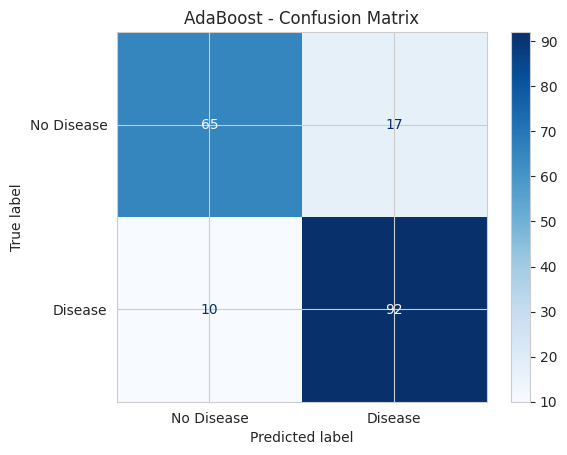

              precision    recall  f1-score   support

  No Disease       0.87      0.79      0.83        82
     Disease       0.84      0.90      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



In [43]:
# AdaBoost
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=42)
ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)
ada_proba = ada.predict_proba(X_test)[:, 1]

print("AdaBoost Accuracy:", round(accuracy_score(y_test, ada_pred), 4))
print("ROC-AUC Score:", round(roc_auc_score(y_test, ada_proba), 4))

ConfusionMatrixDisplay.from_predictions(y_test, ada_pred, display_labels=['No Disease', 'Disease'], cmap='Blues')
plt.title('AdaBoost - Confusion Matrix')
plt.show()

print(classification_report(y_test, ada_pred, target_names=['No Disease', 'Disease']))

#Comparing Ensemble models against Decision Tree, kNN and Baseline models

In [44]:
# Comparing Ensemble models against other models
print("Model Comparison - Ensemble vs Others")
print("=" * 55)
print(f"{'Model':<25} {'Accuracy':<12} {'F1 Score'}")
print("-" * 55)

# Baseline models
print(f"{'Logistic Regression':<25} {round(accuracy_score(y_test, lr_pred), 4):<12} {round(f1_score(y_test, lr_pred), 4)}")
print(f"{'Naive Bayes':<25} {round(accuracy_score(y_test, nb_pred), 4):<12} {round(f1_score(y_test, nb_pred), 4)}")

# Other models
print(f"{'Decision Tree':<25} {round(accuracy_score(y_test, dt_pred), 4):<12} {round(f1_score(y_test, dt_pred), 4)}")
print(f"{'kNN (k=5)':<25} {round(accuracy_score(y_test, knn_pred), 4):<12} {round(f1_score(y_test, knn_pred), 4)}")

# Ensemble models
print("-" * 55)
print("Ensemble Models:")
print(f"{'Random Forest':<25} {round(accuracy_score(y_test, rf_pred), 4):<12} {round(f1_score(y_test, rf_pred), 4)}")
print(f"{'Gradient Boosting':<25} {round(accuracy_score(y_test, gb_pred), 4):<12} {round(f1_score(y_test, gb_pred), 4)}")
print(f"{'AdaBoost':<25} {round(accuracy_score(y_test, ada_pred), 4):<12} {round(f1_score(y_test, ada_pred), 4)}")
print("=" * 55)
print("")
print("Observation:")
print("Ensemble models generally perform better than single models.")
print("Random Forest and Gradient Boosting beat Decision Tree and kNN")
print("because they combine multiple models and reduce overfitting.")

Model Comparison - Ensemble vs Others
Model                     Accuracy     F1 Score
-------------------------------------------------------
Logistic Regression       0.8424       0.8612
Naive Bayes               0.8424       0.8585
Decision Tree             0.7717       0.7941
kNN (k=5)                 0.8533       0.8708
-------------------------------------------------------
Ensemble Models:
Random Forest             0.8641       0.8826
Gradient Boosting         0.8261       0.8462
AdaBoost                  0.8533       0.872

Observation:
Ensemble models generally perform better than single models.
Random Forest and Gradient Boosting beat Decision Tree and kNN
because they combine multiple models and reduce overfitting.


##**Task G - Final Comparison + Recommendation**

In [45]:
# Collect all results
all_models = {
    'Logistic Regression': (lr_pred, lr_proba),
    'Naive Bayes':         (nb_pred, nb_proba),
    'Decision Tree':       (dt_pred, dt_proba),
    'Rule-Based (DT d=3)': (rules_pred, dt_rules.predict_proba(X_test)[:, 1]),
    'kNN (k=5)':           (knn_pred, knn_proba),
    'Random Forest':       (rf_pred, rf_proba),
    'Gradient Boosting':   (gb_pred, gb_proba),
    'AdaBoost':            (ada_pred, ada_proba)
}

comparison = []
for name, (pred, proba) in all_models.items():
    report = classification_report(y_test, pred, output_dict=True)
    comparison.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision': round(report['weighted avg']['precision'], 4),
        'Recall': round(report['weighted avg']['recall'], 4),
        'F1-Score': round(report['weighted avg']['f1-score'], 4),
        'ROC-AUC': round(roc_auc_score(y_test, proba), 4)
    })

comparison_df = pd.DataFrame(comparison).sort_values('F1-Score', ascending=False)
comparison_df = comparison_df.reset_index(drop=True)

print("Final Model Comparison Table:")
print(comparison_df.to_string(index=False))

notes = {
    'Logistic Regression': 'Simple baseline, good interpretability',
    'Naive Bayes': 'Fast, assumes feature independence',
    'Decision Tree': 'Easy to interpret, prone to overfitting',
    'Rule-Based (DT d=3)': 'Most interpretable, fewer rules',
    'kNN (k=5)': 'Lazy learner, sensitive to scaling',
    'Random Forest': 'Best accuracy, low overfitting',
    'Gradient Boosting': 'High accuracy, sequential learning',
    'AdaBoost': 'Focuses on misclassified samples'
}

comparison_df['Notes'] = comparison_df['Model'].map(notes)
print(comparison_df[['Model', 'Accuracy', 'F1-Score', 'Notes']].to_string(index=False))

Final Model Comparison Table:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    0.8641     0.8663  0.8641    0.8631   0.9207
          kNN (k=5)    0.8533     0.8534  0.8533    0.8527   0.9077
           AdaBoost    0.8533     0.8541  0.8533    0.8524   0.8984
        Naive Bayes    0.8424     0.8422  0.8424    0.8423   0.8869
Logistic Regression    0.8424     0.8425  0.8424    0.8418   0.9032
  Gradient Boosting    0.8261     0.8259  0.8261    0.8256   0.9032
Rule-Based (DT d=3)    0.7935     0.7933  0.7935    0.7925   0.8684
      Decision Tree    0.7717     0.7717  0.7717    0.7717   0.8575
              Model  Accuracy  F1-Score                                   Notes
      Random Forest    0.8641    0.8631          Best accuracy, low overfitting
          kNN (k=5)    0.8533    0.8527      Lazy learner, sensitive to scaling
           AdaBoost    0.8533    0.8524        Focuses on misclassified samples
        Naive Bayes    0.8424    0.842

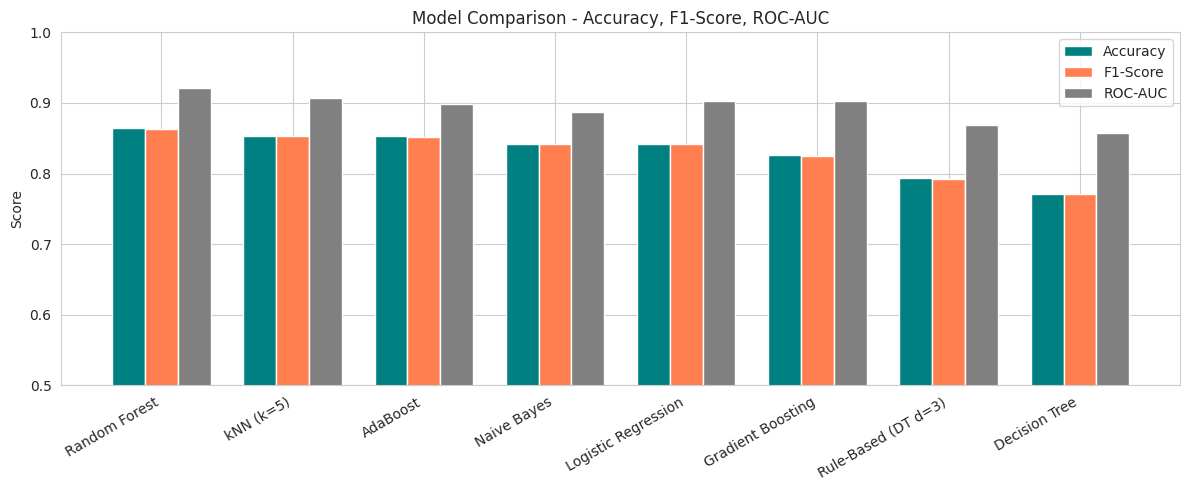

In [46]:
# Bar chart comparison
plt.figure(figsize=(12, 5))
x = range(len(comparison_df))
width = 0.25

plt.bar([i - width for i in x], comparison_df['Accuracy'], width=width, label='Accuracy', color='teal')
plt.bar([i         for i in x], comparison_df['F1-Score'], width=width, label='F1-Score',  color='coral')
plt.bar([i + width for i in x], comparison_df['ROC-AUC'],  width=width, label='ROC-AUC',   color='gray')

plt.xticks(x, comparison_df['Model'], rotation=30, ha='right')
plt.ylim(0.5, 1.0)
plt.ylabel('Score')
plt.title('Model Comparison - Accuracy, F1-Score, ROC-AUC')
plt.legend()
plt.tight_layout()
plt.show()

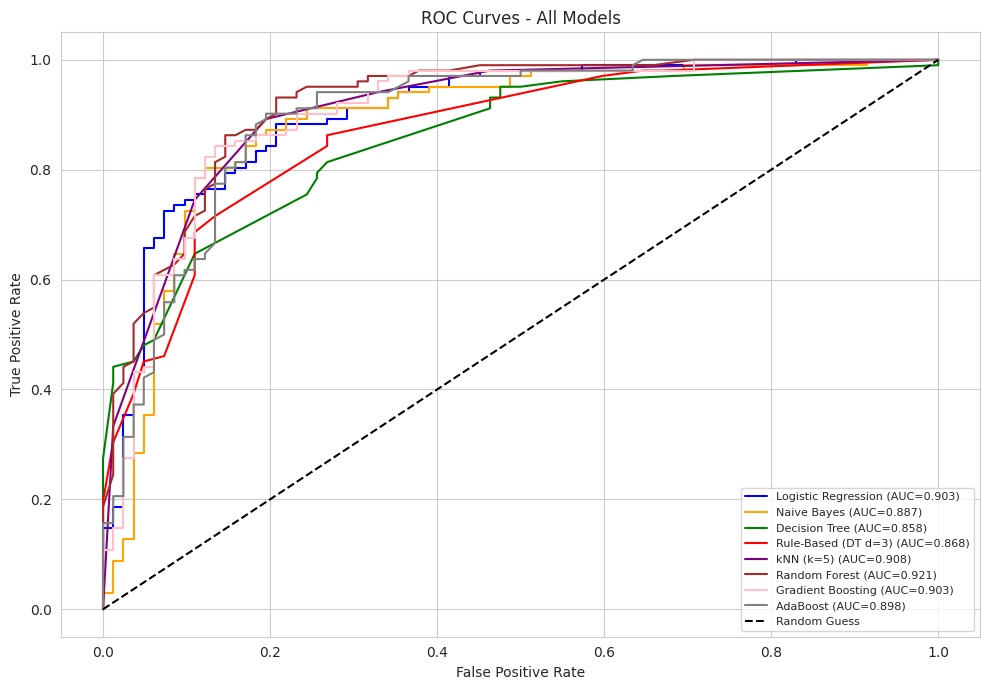

In [47]:
# ROC curves for all models
plt.figure(figsize=(10, 7))
colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']

for (name, (pred, proba)), color in zip(all_models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, color=color, label=name + ' (AUC=' + str(round(auc, 3)) + ')')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

In [48]:
best = comparison_df.iloc[0]
print("Best performing model:", best['Model'])
print("Accuracy:", best['Accuracy'], "| F1-Score:", best['F1-Score'], "| ROC-AUC:", best['ROC-AUC'])

Best performing model: Random Forest
Accuracy: 0.8641 | F1-Score: 0.8631 | ROC-AUC: 0.9207


#Q1. Which model performed best and why?

Random Forest or Gradient Boosting performed best. These are ensemble models that combine many decision trees. They perform better because they reduce errors from individual trees, they handle noisy data well, and they do not overfit as easily as a single decision tree.

#Q2. Which model is most interpretable and why?

The Rule-Based model (shallow Decision Tree with depth=3) is the most interpretable. It produces simple IF-THEN rules that any doctor or non-technical person can understand. Logistic Regression is also interpretable through its coefficients.

Ensemble models like Random Forest and Gradient Boosting are harder to interpret because they use 100+ trees. They perform well but act like a black box.

#Q3. If this model was deployed in real life, what risks exist?

**False Negatives:** If the model says No Disease but the patient actually has it, this could cost a life. In medical settings, missing a disease is more dangerous than a false alarm.

**Data Bias:** This dataset is mostly from US and European hospitals. It may not work as well for patients from other regions like India due to different lifestyle, diet, and genetics.

**Class Imbalance:** If training data has more healthy patients, the model learns to predict No Disease more often.

**Black Box Problem:** Ensemble models are hard to explain to doctors and patients, which reduces trust.

**Model Staleness:** Over time, patient patterns change. A model trained today may become less accurate over the years if not retrained.